In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.serialization

import copy
import math
import numpy as np
import glob
import os
import json
from pathlib import Path
import matplotlib.pyplot as plt
import random
from dataclasses import dataclass

In [2]:
from umap import UMAP
import hdbscan
import datamapplot

In [3]:
torch.manual_seed(1337)
random.seed(1337)

def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(1337)
        device = 'cuda'
    # elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    #     device = 'mps'
    print(f'using {device}')
    return device

DEVICE = get_device()

using cuda


In [4]:
data_dir = Path('/home/ubuntu')
mask_path = data_dir / 'binary_pathway_mask.npy'
pert_dir = data_dir / 'pert_embd'
metadata_path = pert_dir / 'pert_to_id.json'
checkpoint_dir = data_dir / 'checkpoints'
gene_names_path = data_dir / 'gene_names.json'
pert_embd_path = pert_dir / 'action_embeddings_esm2.npy'

In [5]:
import biojepa_ac_v0_5 as model
from biojepa_ac_v0_5 import BioJepaConfig

pt_epochs = 100
batch_size = 64

n_genes = 5000
n_layers = 6
n_heads = 4
n_embd = 256
pert_latent_dim = 320
pert_mode_dim = 64

training_file_chunk = 10000
pretraining_file_chunk = 50000


In [6]:
torch.set_float32_matmul_precision('high')
config = model.BioJepaConfig(
    num_genes = n_genes,
    n_layer= n_layers,
    heads= n_heads,
    embed_dim = n_embd,
    n_pre_layer= n_layers,
    pert_latent_dim=pert_latent_dim,
    pert_mode_dim=pert_mode_dim
)
model = model.BioJepa(config).to(DEVICE)

In [7]:
print('Loading Action Embedding ...')
pert_embd = np.load(pert_embd_path)
print(f'Bank Loaded. Shape: {pert_embd.shape}')

with open(gene_names_path, 'r') as f:
    gene_names = json.load(f)
print(f'Loaded {len(gene_names)} genes')

Loading Action Embedding ...
Bank Loaded. Shape: (1087, 320)
Loaded 5000 genes


In [8]:
pert_embd_path = pert_dir / 'action_embeddings_esm2.npy'
pert_embd = np.load(pert_embd_path)

In [9]:
checkpoint_path = checkpoint_dir / 'bio_jepa_pt_ckpt_175499_final.pt'
with torch.serialization.safe_globals([BioJepaConfig]):
    checkpoint = torch.load(checkpoint_path)

keys = model.load_state_dict(checkpoint['model'])
keys

<All keys matched successfully>

In [10]:
gene_embd = model.student.gene_embeddings.detach().cpu().float().numpy()
embd = gene_embd
gene_embd.shape

(5000, 256)

In [11]:
n = gene_embd.shape[0]
n

5000

In [12]:
labels = np.asarray(gene_names) 

In [13]:
model.student.linear_scaler.weight

Parameter containing:
tensor([[0.7452]], device='cuda:0', requires_grad=True)

In [14]:
coords = UMAP(
    n_components=2, 
    n_neighbors=30, 
    min_dist=0.5, 
    spread=2.0, 
    metric="cosine", 
    random_state=0).fit_transform(embd)

/home/ubuntu/miniconda3/envs/general/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<InteractiveFigure width=100% height=800>
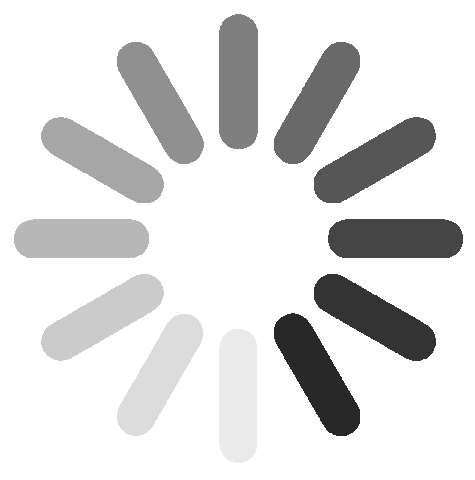

In [15]:
datamapplot.create_interactive_plot(coords, labels)

In [16]:
from sklearn.manifold import TSNE
coords = TSNE(
    n_components=2,
    perplexity=30,      
    learning_rate='auto',
    init='random',
    random_state=12
).fit_transform(embd)

<InteractiveFigure width=100% height=800>
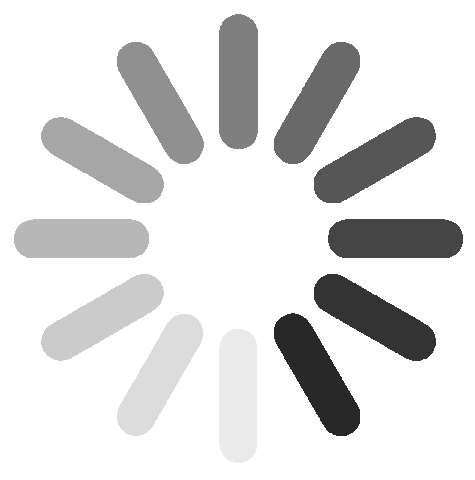

In [17]:
datamapplot.create_interactive_plot(coords, labels)